# Classification Track Preprocessing & EDA
**Dataset**: Dry Bean Dataset
<br>
**Dataset Overview:**
The Dry Bean Dataset contains features extracted from high-resolution images of 13,611 dry beans. The objective is to accurately classify each bean into one of 7 distinct commercial varieties (SEKER, BARBUNYA, BOMBAY, CALI, HOROZ, SIRA, DERMASON). The dataset relies on 16 continuous numeric features detailing the bean's geometry (Area, Perimeter, Axis Lengths) and shape characteristics (Compactness, Eccentricity, Shape Factors).

This notebook trains and evaluates the classification models required by the Capstone Guidelines on the preprocessed dataset.

## Section A - Dataset & EDA
### A1: Dataset loading & audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
import warnings
warnings.filterwarnings('ignore')

# Configure interactive zoomable and resizable figures via ipympl
# (Tip: Use the toolbar magnifying glass to box-zoom, crossed arrows to pan,
#  and drag the bottom-right corner to resize. Switch to '%matplotlib inline' if needed.)
%matplotlib widget
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.max_open_warning'] = 50

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Load dataset
df = pd.read_csv('../data/Dry_Bean_Dataset.csv')

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)


Dataset Shape: (13611, 17)

Data Types:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object


In [2]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [3]:
print("\nClass Distribution:")
print(df['Class'].value_counts())



Class Distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


### A2 & A3: EDA Visualisations & Insight Commentary

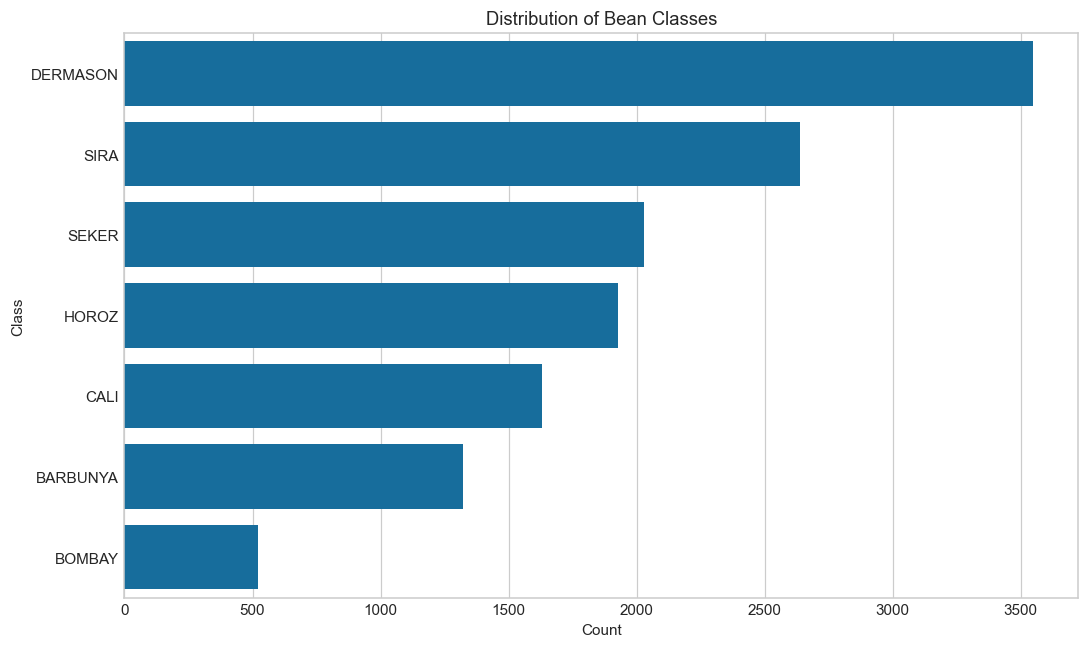

In [4]:
# Target Distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='Class', data=df, order=df['Class'].value_counts().index)
plt.title('Distribution of Bean Classes')
plt.xlabel('Count')
plt.ylabel('Class')
plt.tight_layout()
plt.show()


**Observation (Target Distribution):** The dataset is somewhat imbalanced. The `DERMASON` class is the most frequent, while `BOMBAY` is the rarest. We will use a stratified split to handle this.

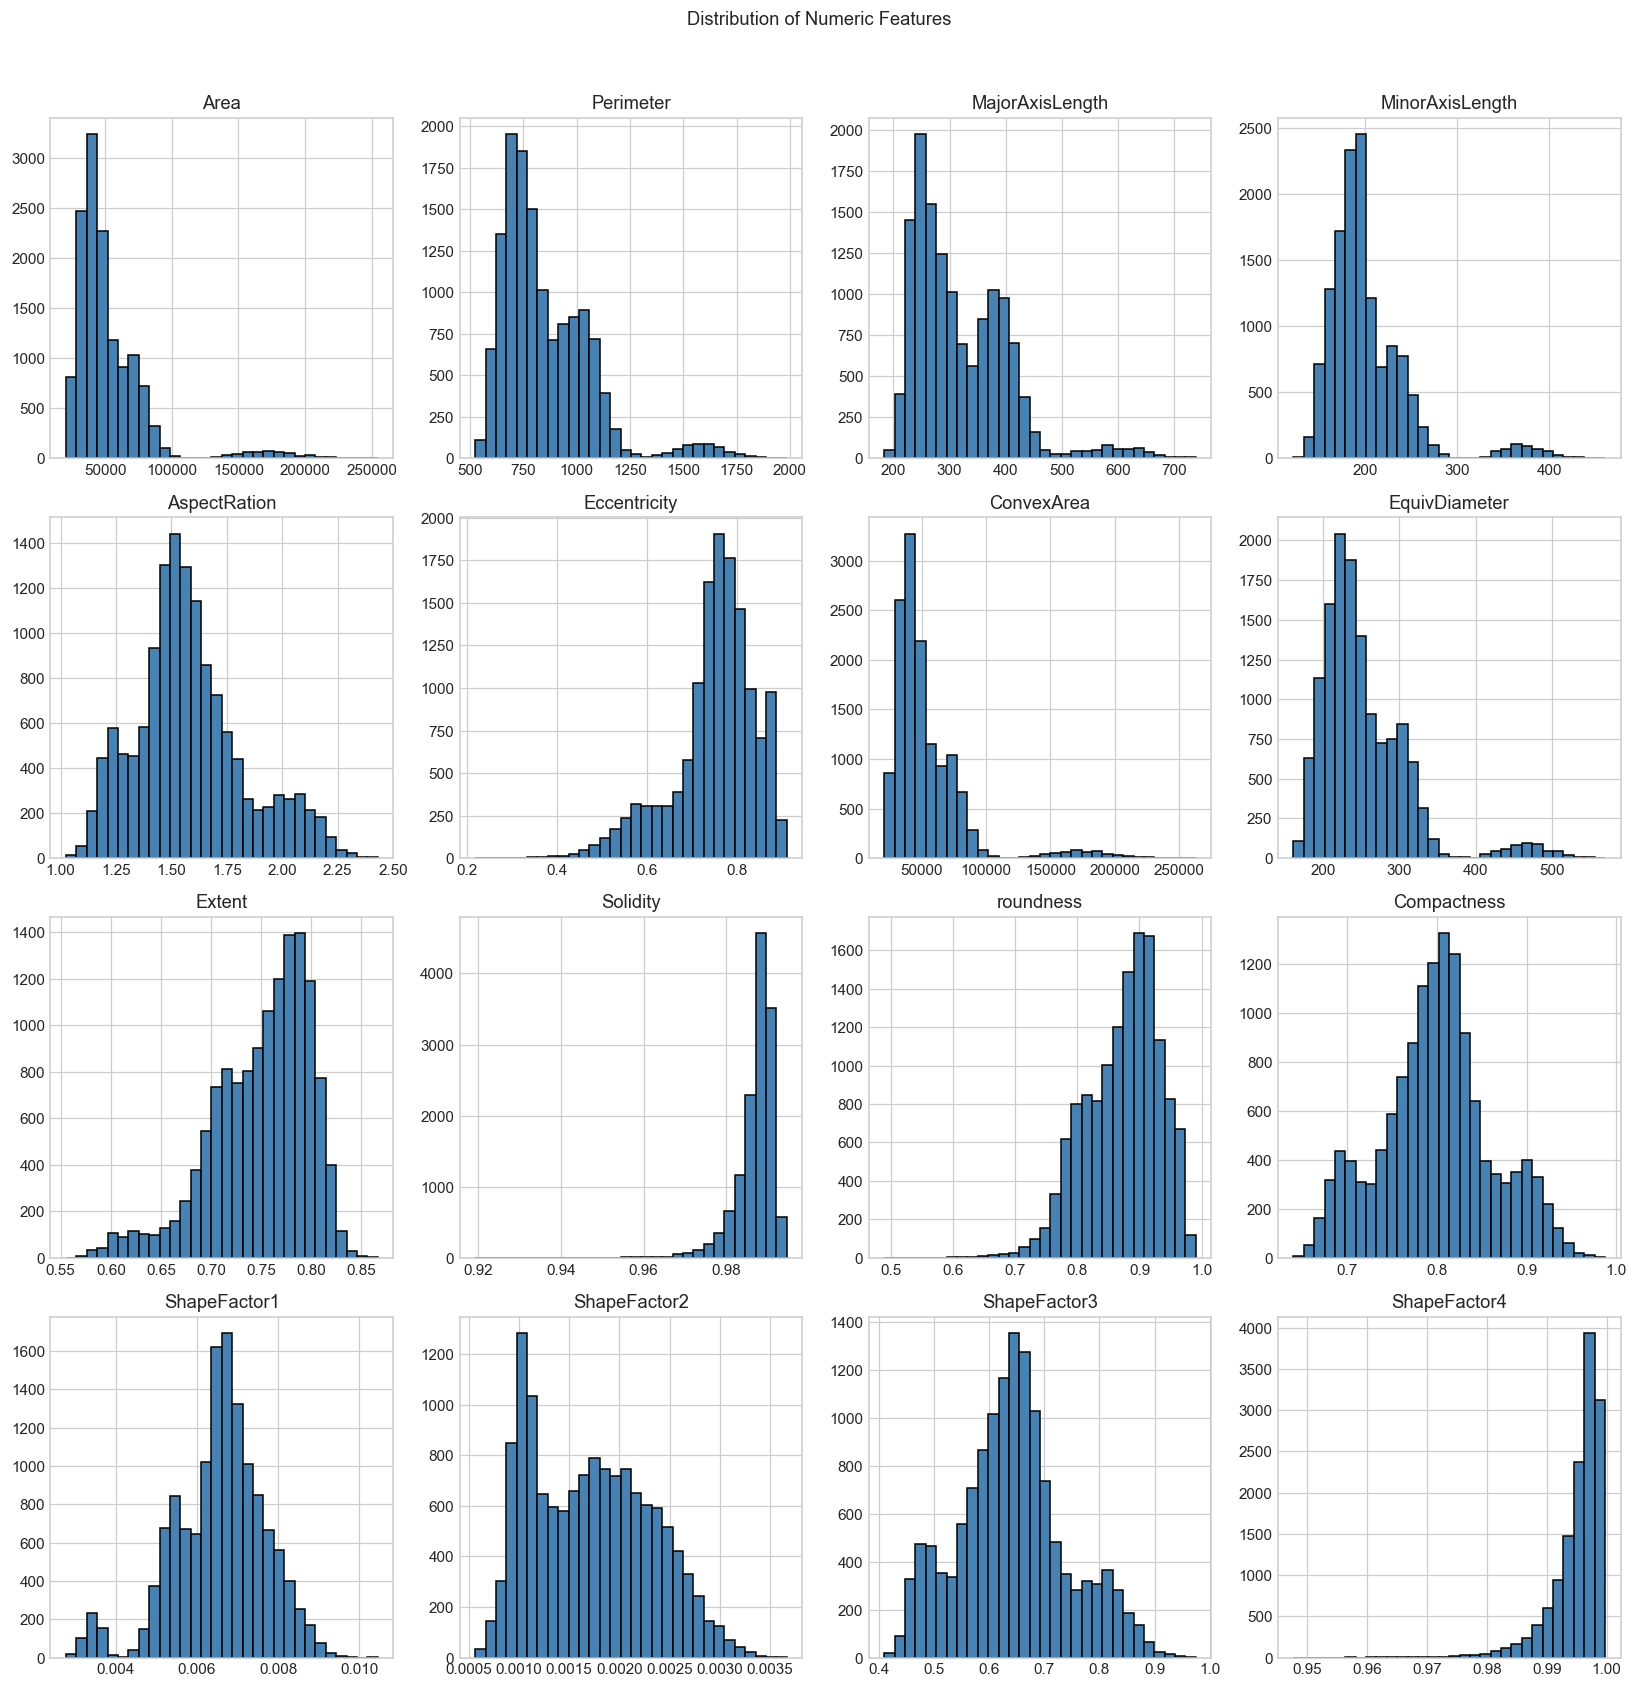

In [5]:
# Feature Distributions (Histograms)
numeric_features = df.select_dtypes(include=[np.number]).columns
df[numeric_features].hist(bins=30, figsize=(15, 15), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Numeric Features', y=1.02)
plt.tight_layout()
plt.show()


**Observation (Distributions):** Several features like Area, ConvexArea, and Perimeter are right-skewed, while Solidity and Extent are left-skewed. Outliers exist in the tails, which we will address during data cleaning.

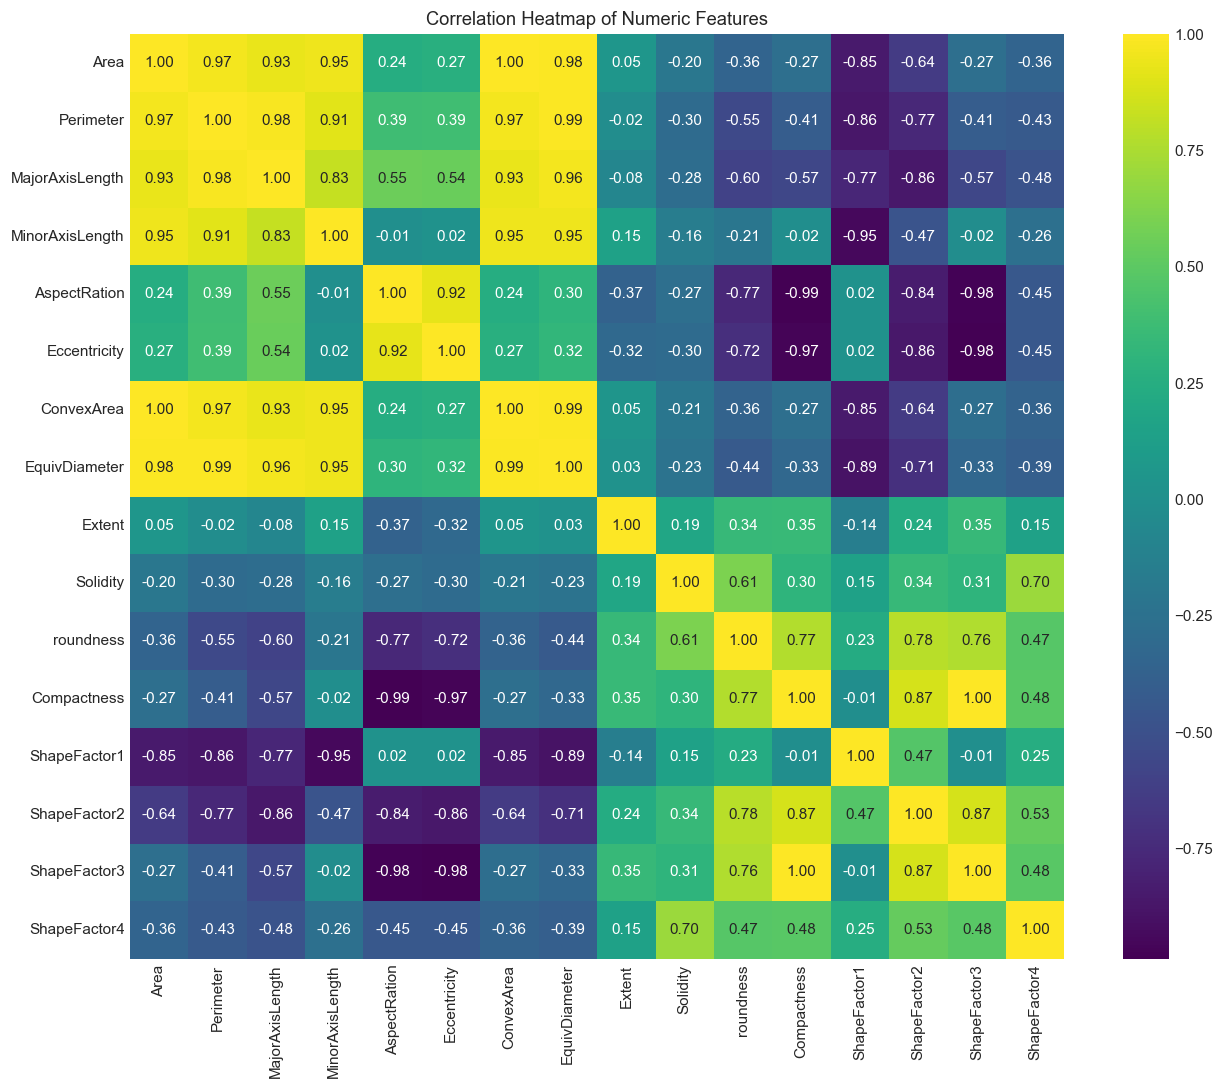

In [6]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


**Observation (Correlation):** There is high multicollinearity among size-related features (`Area`, `Perimeter`, `MajorAxisLength`, `ConvexArea`, `EquivDiameter`). Shape factors (`ShapeFactor1`, `ShapeFactor2`) are negatively correlated with size features.

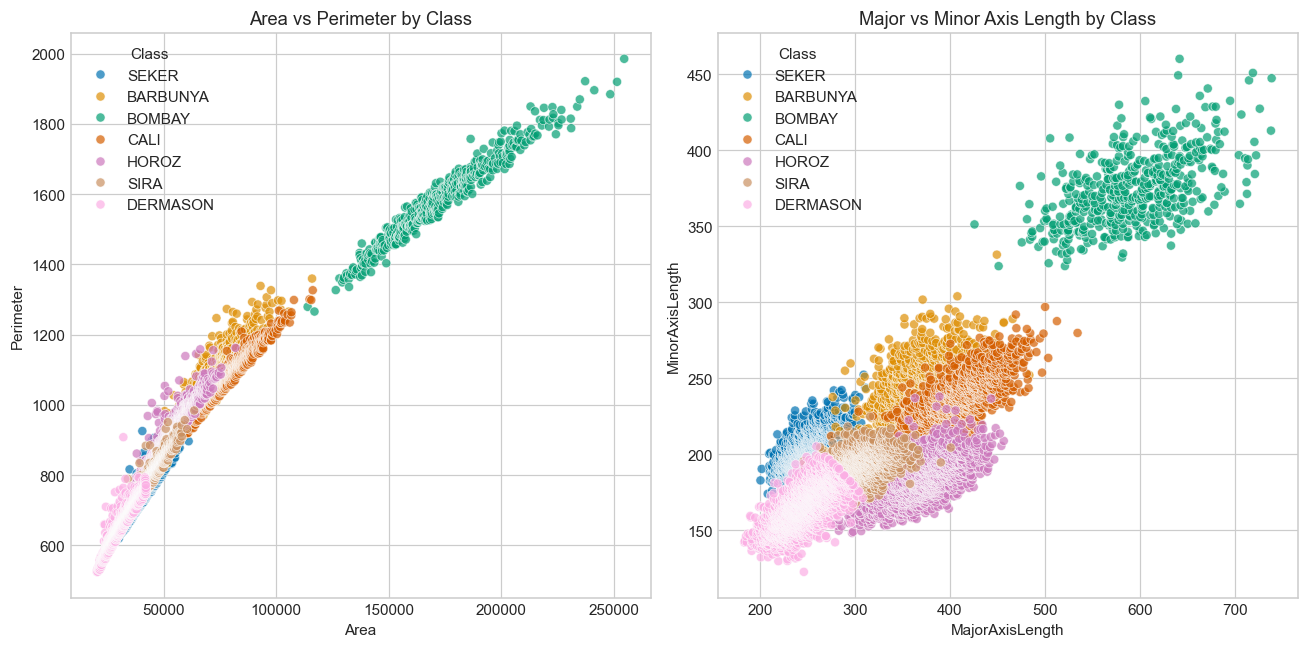

In [7]:
# Scatter Plots showing Feature-Target Relationships
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Area', y='Perimeter', hue='Class', data=df, palette='colorblind', alpha=0.7)
plt.title('Area vs Perimeter by Class')

plt.subplot(1, 2, 2)
sns.scatterplot(x='MajorAxisLength', y='MinorAxisLength', hue='Class', data=df, palette='colorblind', alpha=0.7)
plt.title('Major vs Minor Axis Length by Class')

plt.tight_layout()
plt.show()


**Observation (Scatter Plots):** The scatter plots reveal clear separable clusters for certain classes (like BOMBAY, which is distinctively large in Area and Perimeter). Other classes (like SEKER and DERMASON) cluster closely but have slight differences in their axis lengths.

## Section B - Preprocessing, Quantile Analysis & Feature Engineering

In this section, we clean the dataset, analyze feature quantiles/outliers, engineer a new shape feature, and prepare scaled train/test splits.

### B1: Data Cleaning & Class-Grouped Outlier / Quantile Analysis
- **Duplicate Removal**: Exact duplicate rows are removed to avoid data leakage.
- **Quantile & Outlier Inspection**: We examine feature quantiles across classes. Rather than using a global IQR cutoff (which would delete large beans like `BOMBAY`), we perform class-grouped outlier filtering so every bean variety is preserved properly.


Removed 68 duplicate rows. Shape after duplicate removal: (13543, 17)

--- Feature Quantiles Summary ---
                  5th Pct  25th (Q1)  50th (Median)  75th (Q3)  95th Pct
Area             27645.20   36282.50       44580.00   61382.00  89986.90
Perimeter          617.41     703.23         793.90     977.15   1181.83
MajorAxisLength    224.60     253.09         296.40     376.31    448.64
MinorAxisLength    153.76     175.89         192.49     217.25    268.26
AspectRation         1.21       1.43           1.55       1.70      2.08
Eccentricity         0.56       0.72           0.76       0.81      0.88
ConvexArea       28003.20   36673.00       45122.00   62360.00  91430.30
EquivDiameter      187.61     214.93         238.25     279.56    338.49
Extent               0.66       0.72           0.76       0.79      0.81
Solidity             0.98       0.99           0.99       0.99      0.99
roundness            0.77       0.83           0.88       0.92      0.96
Compactness        

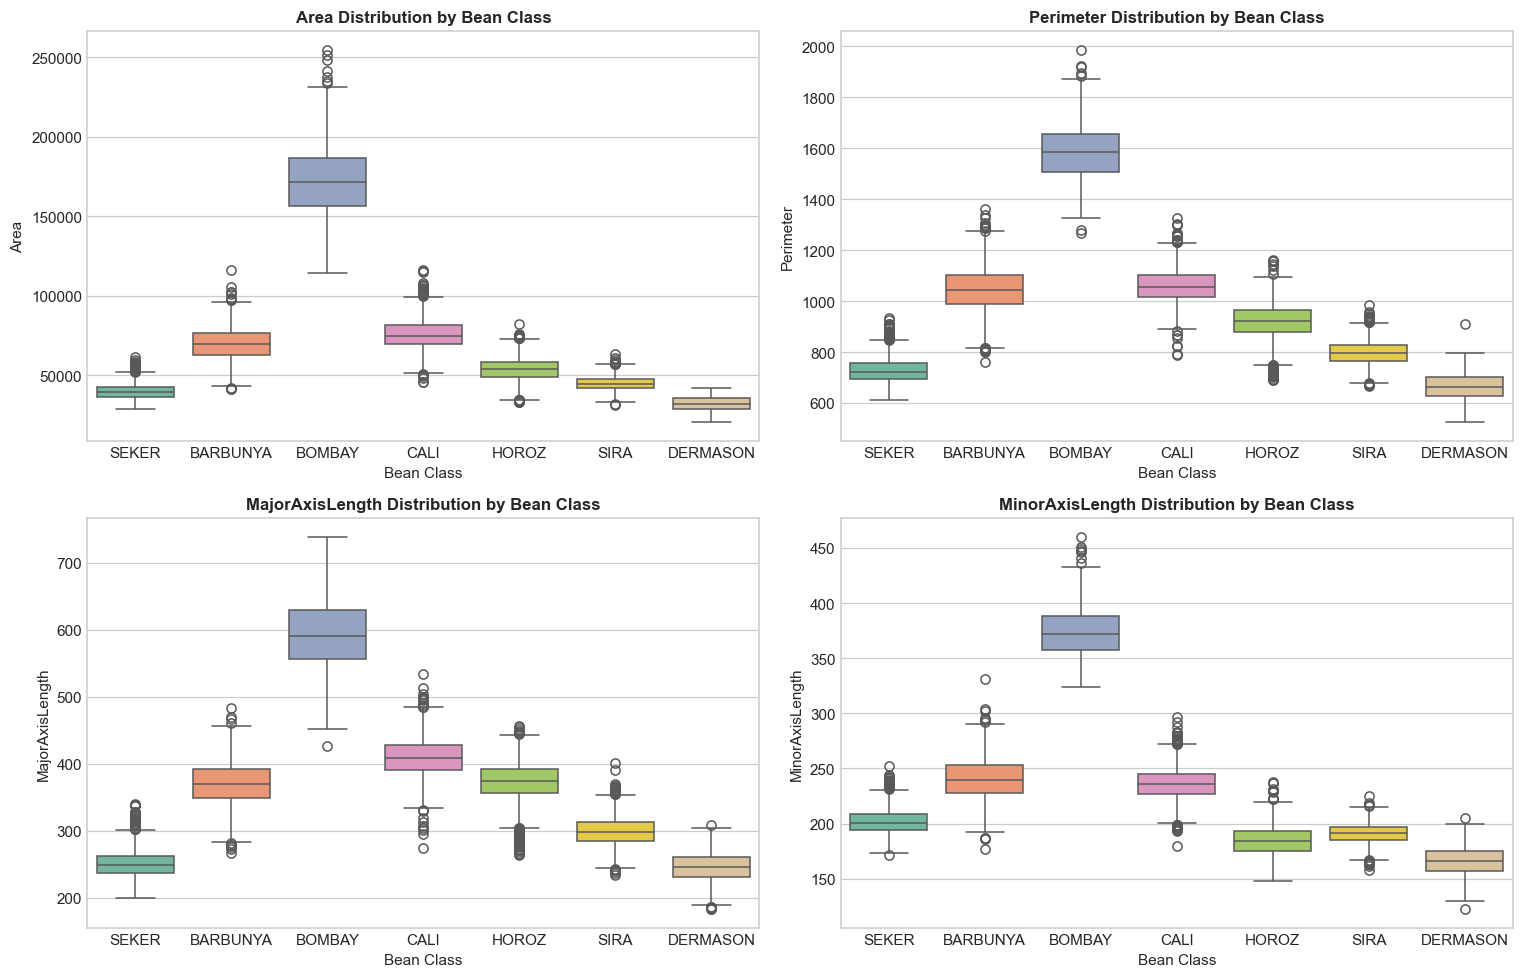


Removed 1665 class-specific outlier rows.
Cleaned Dataset Shape: (11878, 17)

Class counts after grouped outlier removal:
Class
DERMASON    3146
SIRA        2351
SEKER       1730
HOROZ       1558
CALI        1470
BARBUNYA    1159
BOMBAY       464
Name: count, dtype: int64


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import os

# 1. Remove exact duplicates
initial_shape = df.shape
df_no_dup = df.drop_duplicates().copy()
print(f"Removed {initial_shape[0] - df_no_dup.shape[0]} duplicate rows. Shape after duplicate removal: {df_no_dup.shape}")

# 2. Quantile Analysis across key numerical features
num_cols = df_no_dup.select_dtypes(include=[np.number]).columns
quantiles_df = df_no_dup[num_cols].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).T
quantiles_df.columns = ['5th Pct', '25th (Q1)', '50th (Median)', '75th (Q3)', '95th Pct']
print("\n--- Feature Quantiles Summary ---")
print(quantiles_df.round(2))

# Visualize Quantiles & Spread for key dimensional features
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
key_features = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength']

for ax, feature in zip(axes.flatten(), key_features):
    sns.boxplot(x='Class', y=feature, data=df_no_dup, palette='Set2', ax=ax)
    ax.set_title(f"{feature} Distribution by Bean Class", fontsize=11, fontweight='bold')
    ax.set_xlabel("Bean Class")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

# 3. Class-Grouped Outlier Removal using IQR
def remove_outliers_per_class(group):
    q1 = group[num_cols].quantile(0.25)
    q3 = group[num_cols].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    mask = ~((group[num_cols] < lower_bound) | (group[num_cols] > upper_bound)).any(axis=1)
    return group[mask]

df_cleaned = df_no_dup.groupby('Class', group_keys=False).apply(remove_outliers_per_class).reset_index(drop=True)

print(f"\nRemoved {df_no_dup.shape[0] - df_cleaned.shape[0]} class-specific outlier rows.")
print(f"Cleaned Dataset Shape: {df_cleaned.shape}")
print("\nClass counts after grouped outlier removal:")
print(df_cleaned['Class'].value_counts())


### B2: Feature Engineering & Feature-vs-Target Visualizations

We engineer a new geometric ratio feature, `Area_Perimeter_Ratio` ($\text{Area} / \text{Perimeter}$), which captures bean compactness and boundary smoothness. We then plot its distribution and relationship with original shape factors.


Created engineered feature: 'Area_Perimeter_Ratio'


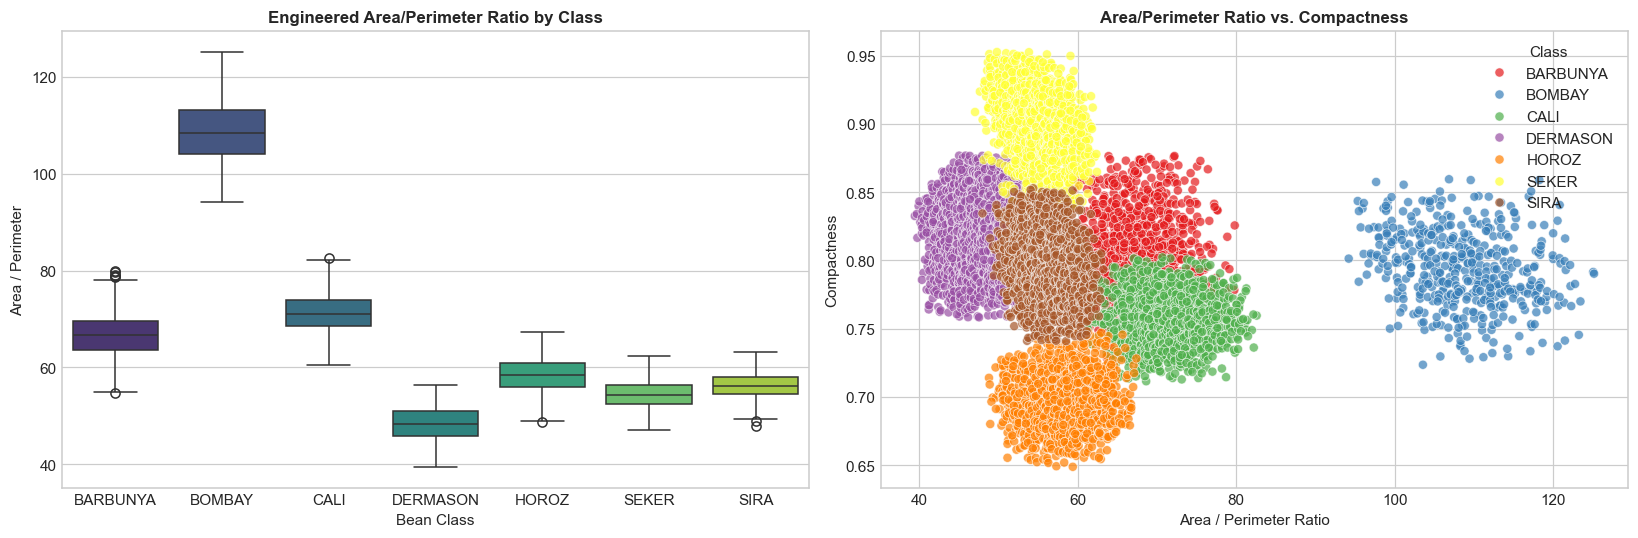

In [9]:
# Create engineered feature
df_cleaned['Area_Perimeter_Ratio'] = df_cleaned['Area'] / df_cleaned['Perimeter']
print("Created engineered feature: 'Area_Perimeter_Ratio'")

# Feature Engineering Diagnostic Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Area_Perimeter_Ratio across Bean Classes
sns.boxplot(x='Class', y='Area_Perimeter_Ratio', data=df_cleaned, palette='viridis', ax=axes[0])
axes[0].set_title("Engineered Area/Perimeter Ratio by Class", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Bean Class")
axes[0].set_ylabel("Area / Perimeter")

# Plot 2: Relationship between Area_Perimeter_Ratio and Compactness
sns.scatterplot(x='Area_Perimeter_Ratio', y='Compactness', hue='Class', data=df_cleaned, alpha=0.7, palette='Set1', ax=axes[1])
axes[1].set_title("Area/Perimeter Ratio vs. Compactness", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Area / Perimeter Ratio")
axes[1].set_ylabel("Compactness")

plt.tight_layout()
plt.show()


### B3: Target Encoding, Stratified Train/Test Split & Feature Scaling

- **Target Encoding**: We map the 7 categorical bean classes into integers (0-6) using `LabelEncoder`.
- **Stratified Split**: We split the dataset into 80% training and 20% testing sets using `random_state=42` with class stratification.
- **Feature Scaling**: `StandardScaler` is fitted **only on the training set** (`X_train`) and then applied to `X_test` to avoid data leakage.


Class Label Mapping: {'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}
X_train shape: (9502, 17)
X_test shape:  (2376, 17)


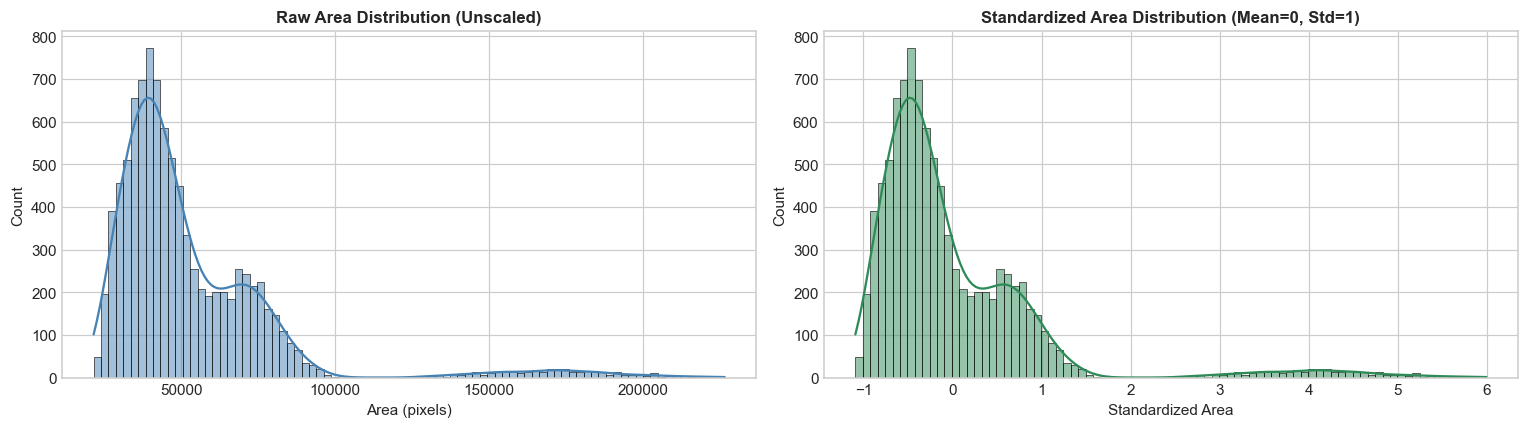

Preprocessed dataset files successfully saved to 'data/classification/'.


In [10]:
# 1. Encode Target Variable
le = LabelEncoder()
X = df_cleaned.drop('Class', axis=1)
y = le.fit_transform(df_cleaned['Class'])

class_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Class Label Mapping:", class_mapping)

# 2. Stratified 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Feature Scaling without Data Leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape:  {X_test_scaled.shape}")

# Visualize Pre- vs. Post-Scaling Distributions for Area
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(X_train['Area'], kde=True, color='steelblue', ax=axes[0])
axes[0].set_title("Raw Area Distribution (Unscaled)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Area (pixels)")

sns.histplot(X_train_scaled['Area'], kde=True, color='seagreen', ax=axes[1])
axes[1].set_title("Standardized Area Distribution (Mean=0, Std=1)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Standardized Area")

plt.tight_layout()
plt.show()

# 4. Save preprocessed splits
os.makedirs('../data/classification', exist_ok=True)
X_train_scaled.to_csv('../data/classification/X_train.csv', index=False)
X_test_scaled.to_csv('../data/classification/X_test.csv', index=False)
pd.DataFrame(y_train, columns=['Class']).to_csv('../data/classification/y_train.csv', index=False)
pd.DataFrame(y_test, columns=['Class']).to_csv('../data/classification/y_test.csv', index=False)

print("Preprocessed dataset files successfully saved to 'data/classification/'.")
